In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd



# start with some U_true in this simulation its 25 parcels (5 main parcels, each with 5 subparcels)

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
# centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [4]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

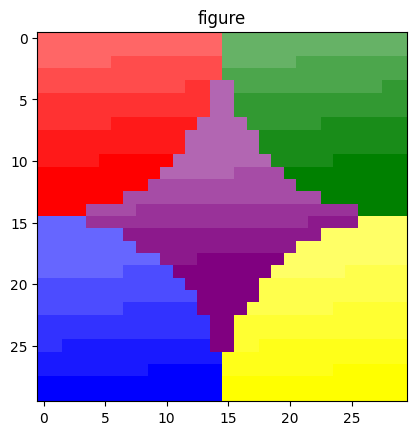

In [5]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

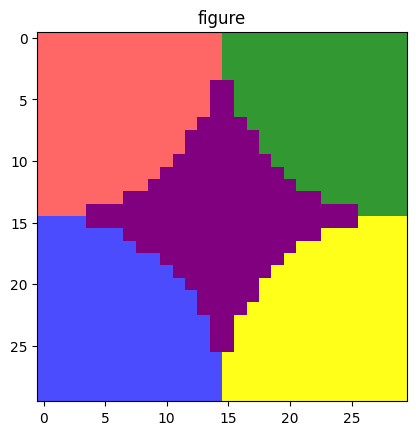

In [6]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
plot_Us(U_true_5)
U_true_5 = U_true_5[np.newaxis, :, :]

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

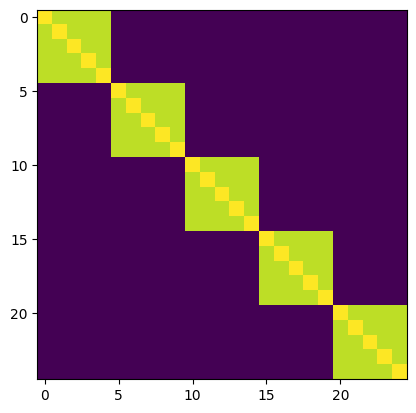

In [7]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.5, sub_parcel_extra_correlation=0.45)
plt.imshow(R)


covariance across tasks G

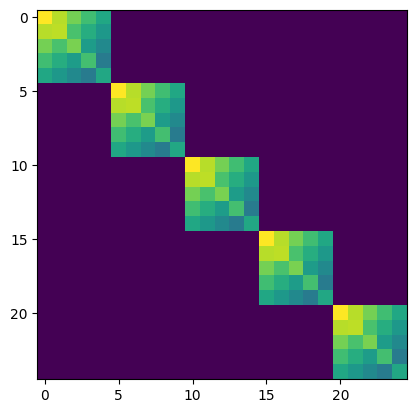

In [8]:
variance_factors = [[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6],[1,0.9,0.8,0.7,0.6]]
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.99, variance_factors=variance_factors)
plt.imshow(G)

make Vs (this num_iter gives a good V)

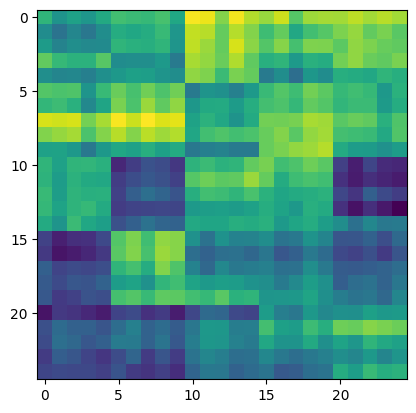

In [9]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=16000,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns  
approximates initial G and R to a good extent

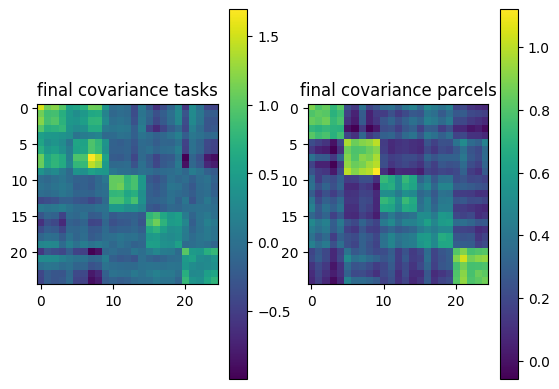

In [10]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()
plt.title('final covariance tasks')

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.title('final covariance parcels')
plt.show()


lower dimensional Vs (just for the 5 main parcels)

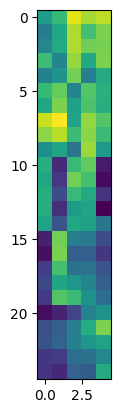

In [11]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data

In [12]:
Y_true = Vs_25 @ np.array(U_true_25)


G matrix used for eigenmetrics

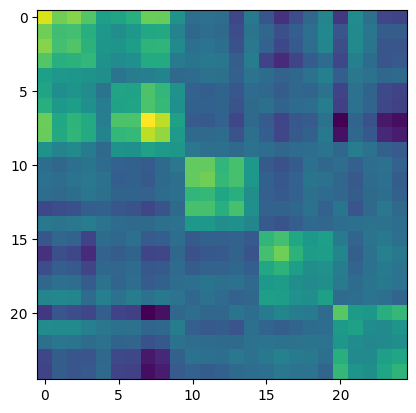

In [13]:
G_lib = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [25]:
D = ut.build_combinations(G_lib, strategy='random',n_iter=2000,n_tasks=4,seed=606,replacement=False)
ytest = Y_true
vtest = Vs_5    
D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, Vs_5, U_true_5, sig_e=0.4, vtest=vtest, ytest=ytest)

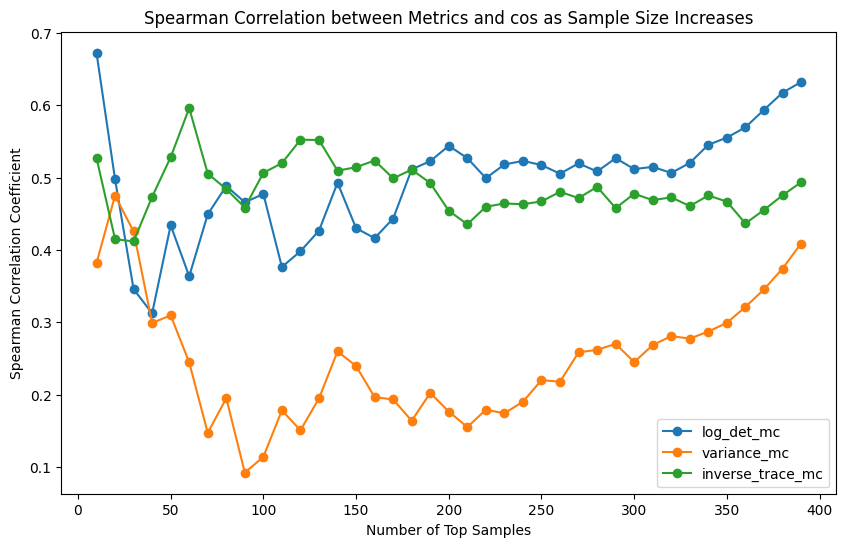

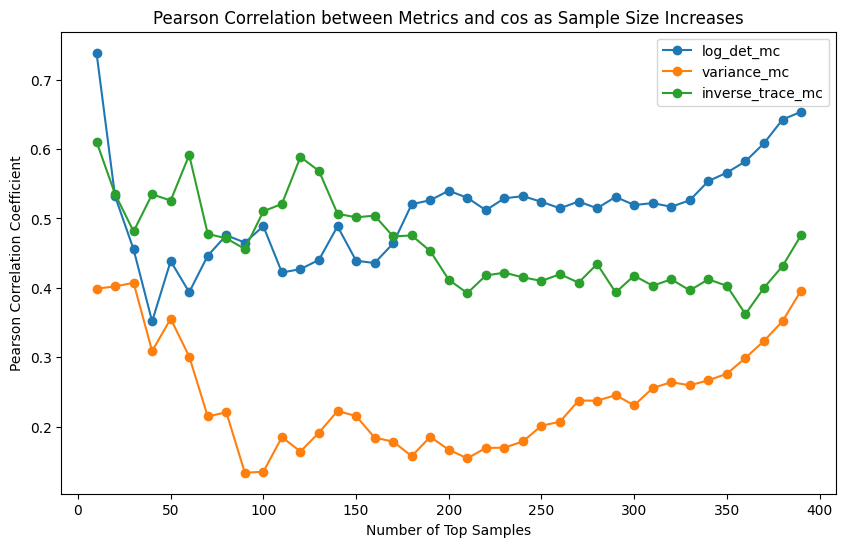

In [24]:
# import spearman correlation
from scipy.stats import spearmanr
from scipy.stats import pearsonr
sample_sizes = range(10, 400, 10) 
metrics = ['log_det_mc', 'variance_mc', 'inverse_trace_mc']

correlation_data = []
for n in sample_sizes:
    for metric in metrics:
        # Get the top n samples based on the metric
        top_n = D_ev.nlargest(n, metric)
        # Compute Spearman correlation
        spearman_corr, _ = spearmanr(top_n['perc'], top_n[metric])
        # Compute Pearson correlation
        pearson_corr, _ = pearsonr(top_n['perc'], top_n[metric])
        # Store the results
        correlation_data.append({
            'Sample Size': n,
            'Metric': metric,
            'Spearman Correlation': spearman_corr,
            'Pearson Correlation': pearson_corr
        })

# Convert the list of dictionaries to a DataFrame
correlation_df = pd.DataFrame(correlation_data)

# Plotting Spearman
plt.figure(figsize=(10, 6))
for metric in metrics:
    subset = correlation_df[correlation_df['Metric'] == metric]
    plt.plot(subset['Sample Size'], subset['Spearman Correlation'], label=metric, marker='o')
plt.title('Spearman Correlation between Metrics and cos as Sample Size Increases')
plt.xlabel('Number of Top Samples')
plt.ylabel('Spearman Correlation Coefficient')
plt.legend()
plt.show()

# Plotting Pearson 
plt.figure(figsize=(10, 6))
for metric in metrics:
    subset = correlation_df[correlation_df['Metric'] == metric]
    plt.plot(subset['Sample Size'], subset['Pearson Correlation'], label=metric, marker='o')
plt.title('Pearson Correlation between Metrics and cos as Sample Size Increases')
plt.xlabel('Number of Top Samples')
plt.ylabel('Pearson Correlation Coefficient')
plt.legend()
plt.show()


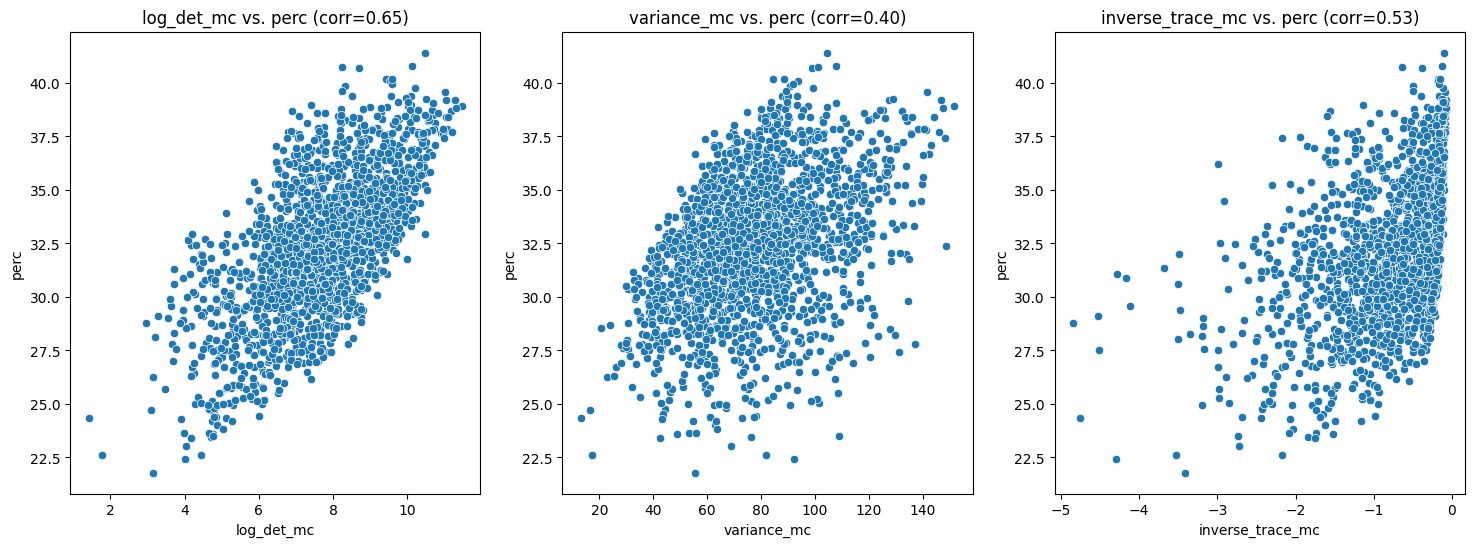

In [16]:

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(data=D_ev, x='log_det_mc', y='perc', ax=ax[0])
sns.scatterplot(data=D_ev, x='variance_mc', y='perc', ax=ax[1])
sns.scatterplot(data=D_ev, x='inverse_trace_mc', y='perc', ax=ax[2])
for i, metric in enumerate(['log_det_mc', 'variance_mc', 'inverse_trace_mc']):
    corr, _ = spearmanr(D['perc'], D[metric])
    ax[i].set_title(f'{metric} vs. perc (corr={corr:.2f})')